In [2]:
import pandas as pd 
import numpy as np 

In [3]:
df = pd.read_csv('data/netflix_titles.csv')
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
missing_data = df.isnull().sum()
print(missing_data)

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [7]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
print(df.isnull().sum())

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64


In [8]:
df.dropna(subset=['date_added','rating','duration'],inplace=True)
print(df.isnull().sum())
print(df.shape)

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64
(8790, 12)


In [9]:
type_counts = df['type'].value_counts()
print("Netflix Content Distribution: ")
print(type_counts)

Netflix Content Distribution: 
type
Movie      6126
TV Show    2664
Name: count, dtype: int64


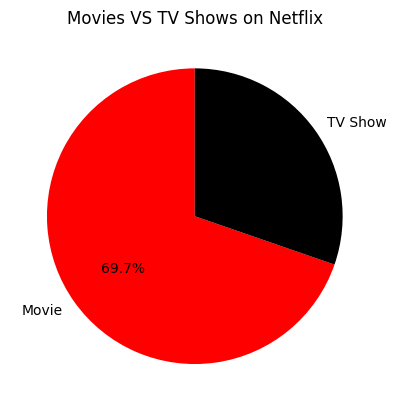

In [10]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()
type_counts.plot(kind='pie', autopct='%1.1f%%',colors=['red','black'],startangle=90)
plt.title('Movies VS TV Shows on Netflix')
plt.ylabel('')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_11432\678689883.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values,y=top_countries.index,palette='rocket')


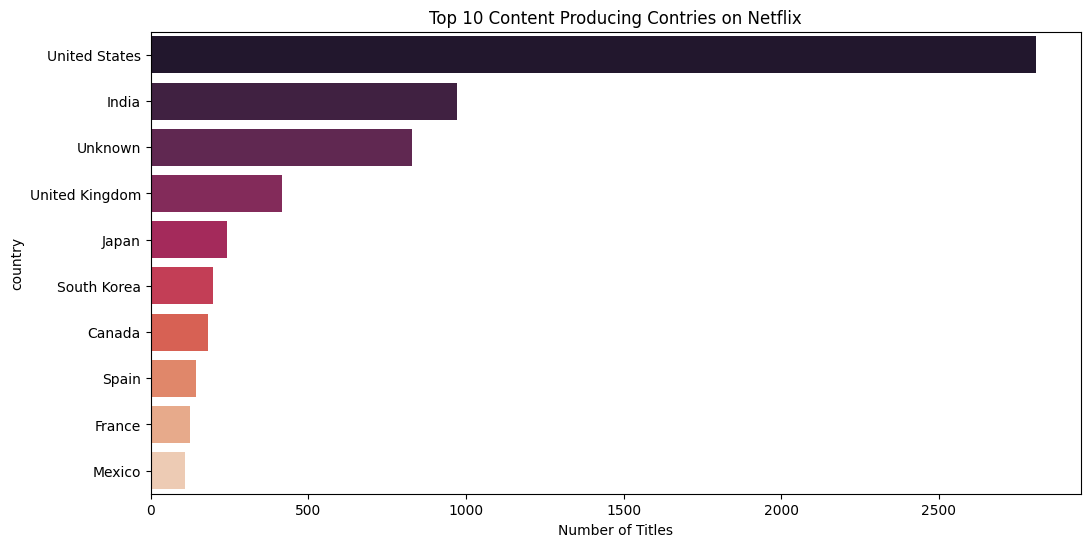

In [11]:
# Top countries

top_countries = df['country'].value_counts().head(10)

import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values,y=top_countries.index,palette='rocket')
plt.title('Top 10 Content Producing Contries on Netflix')
plt.xlabel('Number of Titles')
plt.show()

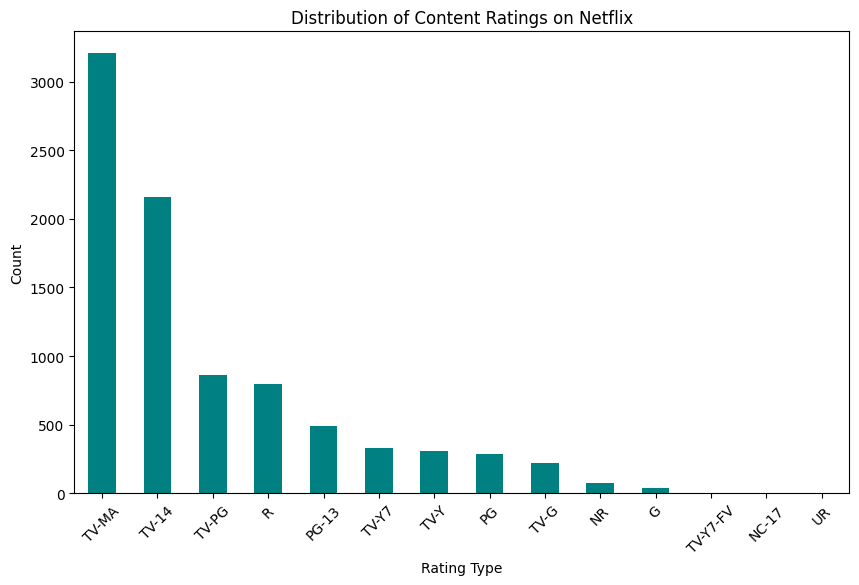

In [12]:
# count of rating

rating_counts = df['rating'].value_counts()

plt.figure(figsize=(10,6))
rating_counts.plot(kind='bar', color='teal')
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

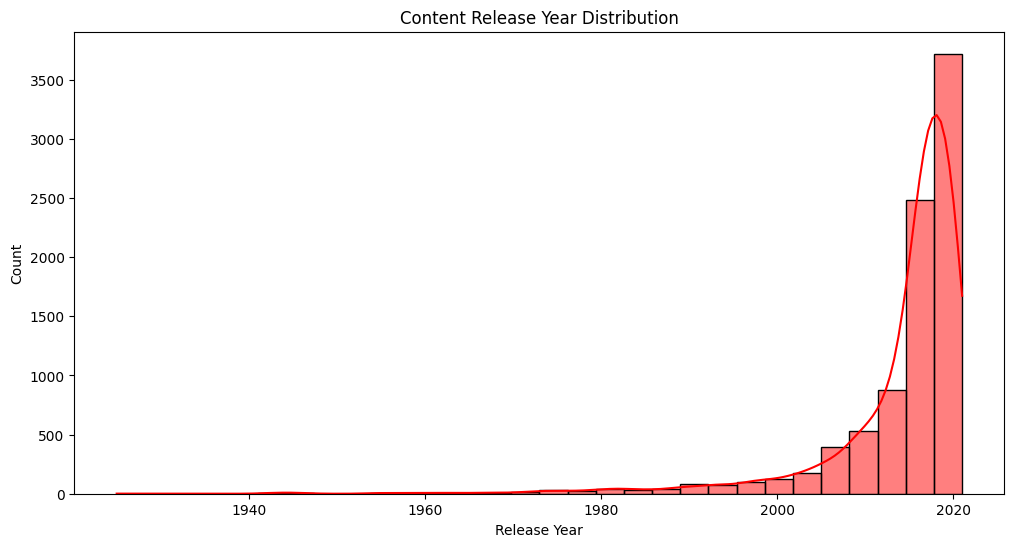

In [13]:
#  Release year

plt.figure(figsize=(12,6))
sns.histplot(df['release_year'], bins=30, kde=True, color='red')
plt.title('Content Release Year Distribution')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

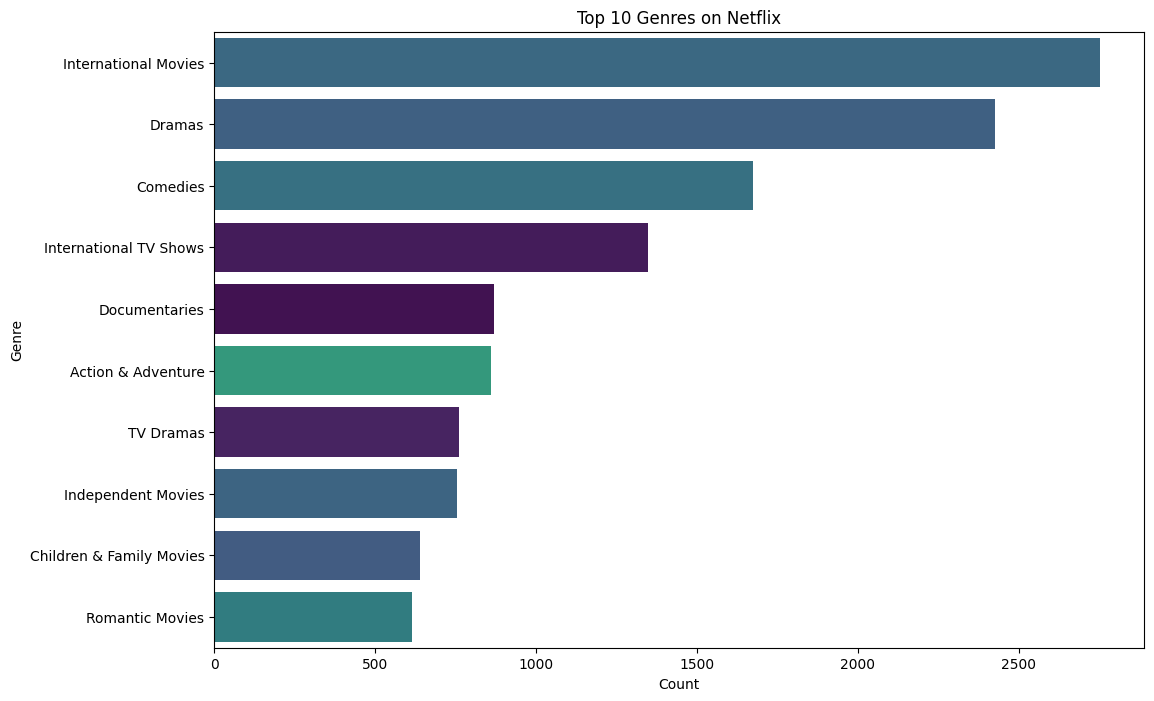

In [14]:
# Top Genres

genres_data = df['listed_in'].str.split(', ').explode().reset_index()

plt.figure(figsize=(12,8))
sns.countplot(data=genres_data, y='listed_in', order=genres_data['listed_in'].value_counts().index[:10],palette='viridis',hue='listed_in', legend=False)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()